In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.insert(0,'../codes/')
import foftools as fof
from group_purity import get_metrics_by_group
from scipy.stats import percentileofscore as pos
from copy import deepcopy

Matplotlib is building the font cache; this may take a moment.


In [2]:
eco = pd.read_csv("/srv/one/zhutchen/g3groupfinder/resolve_and_eco/ECOdata_G3catalog_luminosity.csv").set_index('name')
photzdata = pd.read_csv("/srv/one/hperk4/eco_resb_decals_photoz.csv")

In [3]:
photzdata = photzdata[photzdata.name.str.startswith('ECO')].set_index('name')

In [4]:
photzdata

,spec_z,photo_z,photo_z_corr,e_tab,e_tab_corr
name,,,,,
ECO13218,4995.380486,5353.5,4291.486524,4690.2,3715.760211
ECO02822,6805.777192,7600.8,6703.018575,1814.4,1433.800051
ECO00207,3665.057389,3835.2,2978.639301,1504.8,1188.386247
ECO11747,6772.449470,7311.3,6815.529131,920.4,722.812845
ECO02809,6865.686588,8078.7,7154.884432,9285.6,7340.746142
...,...,...,...,...,...
ECO02650,6245.210387,4344.6,3443.347356,1798.2,1421.074487
ECO11696,3526.419545,2696.7,2144.955723,1541.7,1211.788829
ECO10811,7408.910632,5644.5,4585.306889,2561.4,2029.153226


In [5]:
eco = pd.concat([eco,photzdata],axis=1)

In [6]:
eco = eco[eco.absrmag<=-19.5]

In [43]:
degradedcz = deepcopy(eco.cz.to_numpy())
zphot = deepcopy(eco.photo_z_corr.to_numpy())
zphoterr = deepcopy(eco.e_tab_corr.to_numpy())
degradedczerr = np.zeros_like(degradedcz)+35

idx = np.random.choice(np.indices(degradedcz.shape)[0], size=int(0.85*len(degradedcz)), replace=False)
degradedcz[idx] = zphot[idx]
degradedczerr[idx] = zphoterr[idx]
sel = np.isnan(degradedcz)
degradedcz[sel] = eco.cz.to_numpy()[sel]
degradedczerr[sel] = 35

In [44]:
eco.loc[:,'degradedcz'] = degradedcz
eco.loc[:,'degradedczerr'] = degradedczerr 

In [45]:
fofid = fof.fast_fof(eco.radeg, eco.dedeg, eco.cz, 0.07, 1.1, s=4.84)

FoF complete in 1.3358 s


In [46]:
pfofid = fof.fast_pfof(eco.radeg, eco.dedeg, eco.degradedcz, eco.degradedczerr, 0.07*4.84, 1.1*4.484*100, Pth=0.01)

PFoF complete in 4.6108 s


In [47]:
eco.loc[:,'fofid'] = fofid
eco.loc[:,'pfofid'] = pfofid

In [48]:
pur, comp = get_metrics_by_group(eco.pfofid, eco.fofid, eco.absrmag)

/srv/one/zhutchen/paper3/analysis/../codes/group_purity.py:62: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  hh = mode(haloid[groupsel][sortidx])[0][0]


In [49]:
eco.loc[:,'pur'] = pur
eco.loc[:,'comp'] = comp
eco.loc[:,'grpn'] = fof.multiplicity_function(eco.pfofid,return_by_galaxy=True)

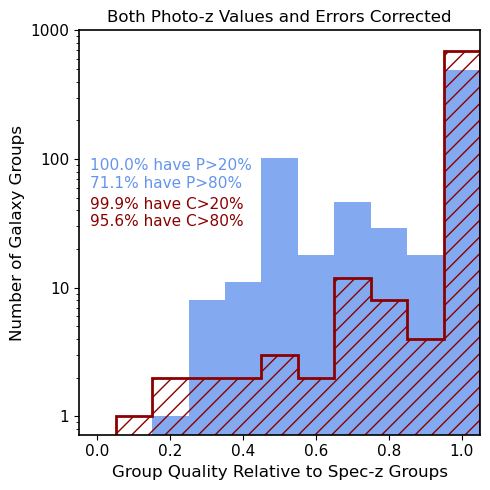

In [50]:
tmp = eco.groupby('pfofid').first()
tmp = tmp[tmp.grpn>1]

plt.figure(figsize=(5,5))
bins=np.arange(-0.05,1.15,0.1)
plt.hist(tmp.pur,bins=bins, label='Purity (Median = {:0.1f}%)'.format(100*np.median(tmp.pur)), alpha=0.8, color='cornflowerblue')
plt.hist(tmp.comp,bins=bins,histtype='step', linewidth=2, label='Completeness (Median = {:0.1f}%)'.format(100*np.median(tmp.comp)), color='darkred', hatch='//')
#plt.legend(loc='best',fontsize=12,framealpha=0)
plt.xlabel("Group Quality Relative to Spec-z Groups", fontsize=12)
plt.ylabel("Number of Galaxy Groups", fontsize=12)#, labelpad=-3)
plt.yscale('log')
plt.xlim(-0.05,1.05)
plt.xticks(np.arange(0,1.1,0.2),fontsize=11)
ytks = [1,10,100,1000]
plt.yticks(ytks)
plt.gca().set_yticklabels(ytks,fontsize=11)
[edge.set_linewidth(1.2) for edge in plt.gca().spines.values()]
#plt.annotate("Only Photo-z Errors Corrected",xy=(0.0,160),fontsize=12, color='darkred')
plt.title("Both Photo-z Values and Errors Corrected",fontsize=12)


purity50 = len(tmp[tmp.pur>0.2])/len(tmp)*100#pos(tmp.pur.to_numpy(), 0.5)
purity90 = len(tmp[tmp.pur>0.8])/len(tmp)*100
plt.annotate("{:0.1f}% have P>20%\n{:0.1f}% have P>80%".format(purity50,purity90), xy=(-0.02,60),fontsize=11, color='cornflowerblue')
comp50 = len(tmp[tmp.comp>0.2])/len(tmp)*100#pos(tmp.pur.to_numpy(), 0.5)
comp90 = len(tmp[tmp.comp>0.8])/len(tmp)*100
plt.annotate("{:0.1f}% have C>20%\n{:0.1f}% have C>80%".format(comp50,comp90), xy=(-0.02,30),fontsize=11,color='darkred')

plt.tight_layout()
plt.savefig("./both_corrected.jpg",dpi=300)
plt.show()

In [ ]:
tmp[['pur','comp','grpn']].quantile(0.5)

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(tmp.grpn, tmp.pur, s=15, marker='s', edgecolor='cornflowerblue', facecolor='None', label='Purity')
plt.scatter(tmp.grpn, tmp.comp, s=5, color='k', label='Completeness')
plt.xlabel(r"Spec-z Group $N_{\rm galaxies}$",fontsize=11)
plt.ylabel("Group Quality Relative to Spec-z Groups",fontsize=11)
plt.xlim(1,300)
plt.xscale('log')
plt.legend(loc='best')
plt.annotate("Only Photo-z Errors\nCorrected",xy=(10,0.15),fontsize=12, color='darkred')
[edge.set_linewidth(1.2) for edge in plt.gca().spines.values()]
plt.xticks([1, 10, 100])
plt.gca().set_xticklabels([1,10,100], fontsize=11)
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.gca().set_yticklabels([0.0,0.2,0.4,0.6,0.8,1.0],fontsize=11)
plt.tight_layout()
plt.savefig("./errors_only_grpn.jpg",dpi=300)
plt.show()

print(tmp[['pur','comp']].mean())

In [ ]:
plt.scatter(degradedcz, eco.cz)
plt.xlim(1000,10000)
plt.ylim(1000,10000)